In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu từ tập tin geyser.csv
data = pd.read_csv('geyser.csv')
data.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


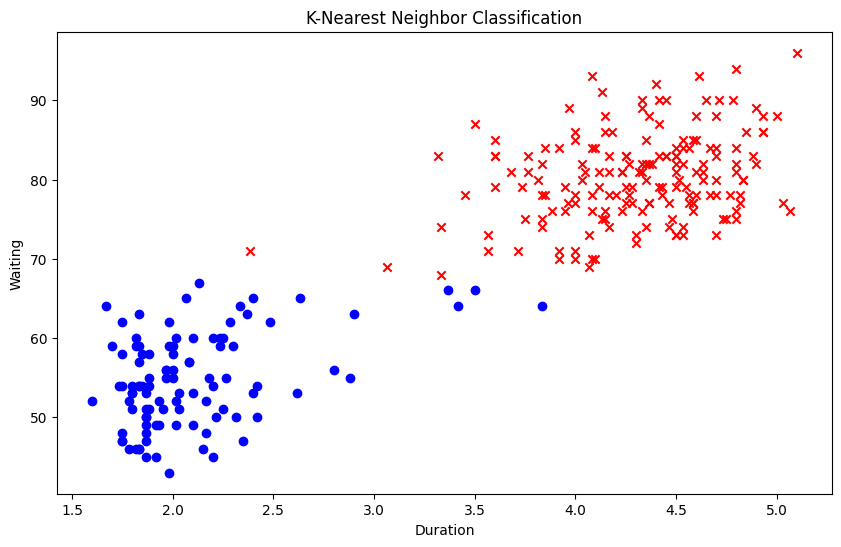

In [4]:

X = data[['duration', 'waiting']].values
y = data['kind'].values

# hàm tính khoảng cách Euclidean giữa hai điểm
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# hàm K-Nearest Neighbor
def k_nearest_neighbors(X, y, query_point, k=3):
    distances = []
    for i in range(len(X)):
        distance = euclidean_distance(query_point, X[i])
        distances.append((distance, y[i]))

    # Sắp xếp các điểm theo khoảng cách tăng dần
    distances.sort(key=lambda x: x[0])

    # Chọn ra k điểm gần nhất
    k_nearest = distances[:k]

    # Đếm số lượng điểm của từng lớp trong k điểm gần nhất
    class_votes = {}
    for distance, label in k_nearest:
        if label in class_votes:
            class_votes[label] += 1
        else:
            class_votes[label] = 1

    # Chọn lớp có số lượng điểm nhiều nhất trong k điểm gần nhất
    predicted_class = max(class_votes, key=class_votes.get)

    return predicted_class

plt.figure(figsize=(10, 6))

for i in range(len(X)):
    point = X[i]
    label = k_nearest_neighbors(X, y, point, k=3)
    if label == 'short':
        plt.scatter(point[0], point[1], c='blue', marker='o', label='Short')
    else:
        plt.scatter(point[0], point[1], c='red', marker='x', label='Long')

plt.xlabel('Duration')
plt.ylabel('Waiting')
# plt.legend(loc='upper right')
plt.title('K-Nearest Neighbor Classification')
plt.show()
